1. Install required packages

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost catboost tensorflow pillow joblib

2. Import libraries

In [3]:
import os
import json
import zipfile
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


3. Set paths

In [4]:
DATASET_PATH = "/content/dataset.csv"
ZIP_PATH = "/content/images.zip"

EXTRACT_DIR = "/content/extracted_images"
IMAGE_DIR = EXTRACT_DIR

OUTPUT_DIR = "/content/outputs"
MODEL_DIR = "/content/models"

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 30

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

4. Extract images.zip

In [5]:
print("Files in /content:")
print(os.listdir("/content"))

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"images.zip not found at: {ZIP_PATH}")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Images extracted to:", EXTRACT_DIR)

Files in /content:
['.config', 'dataset.csv', '.ipynb_checkpoints', 'images.zip', 'extracted_images', 'outputs', 'models', 'sample_data']
Images extracted to: /content/extracted_images


5. List extracted images

In [7]:
image_extensions = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff")

image_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print("Total extracted images:", len(image_files))
print("First 10 image paths:")
image_files[:10]

Total extracted images: 200
First 10 image paths:


['/content/extracted_images/output_images/sample_65.jpg',
 '/content/extracted_images/output_images/sample_20.jpg',
 '/content/extracted_images/output_images/sample_78.jpg',
 '/content/extracted_images/output_images/sample_51.jpg',
 '/content/extracted_images/output_images/sample_93.jpg',
 '/content/extracted_images/output_images/sample_53.jpg',
 '/content/extracted_images/output_images/sample_27.jpg',
 '/content/extracted_images/output_images/sample_88.jpg',
 '/content/extracted_images/output_images/sample_95.jpg',
 '/content/extracted_images/output_images/sample_71.jpg']

6. Load dataset

In [8]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"dataset.csv not found at: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully
Dataset shape: (100, 8)


,oil_mass,volume,density,ph_value,image_name,oil_type,quality_category,result
0,56.77,25,2.2708,5.98,sample_01.jpg,bark,premium,pass
1,58.78,25,2.3512,5.70,sample_02.jpg,bark,good,pass
2,52.31,25,2.0924,6.88,sample_03.jpg,bark,adulterated,fail
3,50.02,25,2.0008,6.35,sample_04.jpg,bark,premium,pass
4,49.22,25,1.9688,6.15,sample_05.jpg,leaf,adulterated,fail


7. Inspect dataset columns

In [9]:
print("Columns:")
for col in df.columns:
    print("-", col)

print("\nData types:")
display(df.dtypes)

print("\nDataset summary:")
display(df.describe(include="all").T)

Columns:
- oil_mass
- volume
- density
- ph_value
- image_name
- oil_type
- quality_category
- result

Data types:


,0
oil_mass,float64
volume,int64
density,float64
ph_value,float64
image_name,object
oil_type,object
quality_category,object
result,object



Dataset summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
oil_mass,100.0,NaN,NaN,NaN,54.4905,3.434358,48.11,51.9875,55.275,57.075,59.92
volume,100.0,NaN,NaN,NaN,25.0,0.0,25.0,25.0,25.0,25.0,25.0
density,100.0,NaN,NaN,NaN,2.17962,0.137374,1.9244,2.0795,2.211,2.283,2.3968
ph_value,100.0,NaN,NaN,NaN,6.7967,0.697409,5.51,6.12,6.945,7.4275,7.9
image_name,100,100,sample_01.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oil_type,100,2,bark,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_category,100,3,premium,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,100,2,pass,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN


8. Detect image filename column

In [10]:
def looks_like_image_filename(value):
    if pd.isna(value):
        return False
    value = str(value).lower().strip()
    return value.endswith(image_extensions)

image_candidate_scores = {}

for col in df.columns:
    values = df[col].dropna().astype(str)
    if len(values) == 0:
        image_candidate_scores[col] = 0
    else:
        image_candidate_scores[col] = values.apply(looks_like_image_filename).mean()

image_column = max(image_candidate_scores, key=image_candidate_scores.get)

if image_candidate_scores[image_column] == 0:
    possible_cols = [
        col for col in df.columns
        if any(word in col.lower() for word in ["image", "img", "photo", "filename", "file"])
    ]
    image_column = possible_cols[0] if possible_cols else None

print("Image candidate scores:")
print(image_candidate_scores)

print("Detected image column:", image_column)

Image candidate scores:
{'oil_mass': np.float64(0.0), 'volume': np.float64(0.0), 'density': np.float64(0.0), 'ph_value': np.float64(0.0), 'image_name': np.float64(1.0), 'oil_type': np.float64(0.0), 'quality_category': np.float64(0.0), 'result': np.float64(0.0)}
Detected image column: image_name


9. Detect target column

In [11]:
target_keywords = [
    "purity",
    "target",
    "result",
    "quality",
    "quality_category",
    "label",
    "class"
]

target_candidates = []

for col in df.columns:
    if col == image_column:
        continue

    col_lower = col.lower()

    if any(keyword in col_lower for keyword in target_keywords):
        target_candidates.append(col)

print("Possible target columns:", target_candidates)

if len(target_candidates) == 0:
    TARGET_COLUMN = None
else:
    TARGET_COLUMN = target_candidates[0]

print("Auto-selected target column:", TARGET_COLUMN)

Possible target columns: ['quality_category', 'result']
Auto-selected target column: quality_category


10. Manually set target column if needed

In [12]:
# TARGET_COLUMN = "purity"
# TARGET_COLUMN = "purity_percentage"
# TARGET_COLUMN = "quality_category"
# TARGET_COLUMN = "result"

if TARGET_COLUMN is None:
    raise ValueError("Target column was not detected. Please manually set TARGET_COLUMN.")

print("Final image column:", image_column)
print("Final target column:", TARGET_COLUMN)

Final image column: image_name
Final target column: quality_category


11. Match CSV image names with extracted images

In [13]:
if image_column is None:
    raise ValueError("Image column was not detected. Please manually set image_column.")

# Create filename lookup
image_lookup = {}

for path in image_files:
    filename = os.path.basename(path)
    image_lookup[filename] = path

def find_image_path(image_name):
    image_name = str(image_name)
    base_name = os.path.basename(image_name)

    if base_name in image_lookup:
        return image_lookup[base_name]

    return None

df["image_path"] = df[image_column].apply(find_image_path)
df["image_exists"] = df["image_path"].notnull()

print("Total rows:", len(df))
print("Images found:", df["image_exists"].sum())
print("Images missing:", (~df["image_exists"]).sum())

if (~df["image_exists"]).sum() > 0:
    print("Missing image examples:")
    display(df.loc[~df["image_exists"], [image_column]].head(20))

display(df.head())

Total rows: 100
Images found: 100
Images missing: 0


,oil_mass,volume,density,ph_value,image_name,oil_type,quality_category,result,image_path,image_exists
0,56.77,25,2.2708,5.98,sample_01.jpg,bark,premium,pass,/content/extracted_images/output_images/sample...,True
1,58.78,25,2.3512,5.70,sample_02.jpg,bark,good,pass,/content/extracted_images/output_images/sample...,True
2,52.31,25,2.0924,6.88,sample_03.jpg,bark,adulterated,fail,/content/extracted_images/output_images/sample...,True
3,50.02,25,2.0008,6.35,sample_04.jpg,bark,premium,pass,/content/extracted_images/output_images/sample...,True
4,49.22,25,1.9688,6.15,sample_05.jpg,leaf,adulterated,fail,/content/extracted_images/output_images/sample...,True


12. Clean dataset

In [14]:
df_clean = df.dropna(subset=[TARGET_COLUMN]).copy()

df_image_clean = df_clean[df_clean["image_exists"]].copy()

print("Original dataset shape:", df.shape)
print("After removing missing target:", df_clean.shape)
print("Rows with valid images:", df_image_clean.shape)

Original dataset shape: (100, 10)
After removing missing target: (100, 10)
Rows with valid images: (100, 10)


**EDA**

13. Dataset overview

In [15]:
print("Dataset shape:", df_clean.shape)
display(df_clean.head())
display(df_clean.describe(include="all").T)

Dataset shape: (100, 10)


,oil_mass,volume,density,ph_value,image_name,oil_type,quality_category,result,image_path,image_exists
0,56.77,25,2.2708,5.98,sample_01.jpg,bark,premium,pass,/content/extracted_images/output_images/sample...,True
1,58.78,25,2.3512,5.70,sample_02.jpg,bark,good,pass,/content/extracted_images/output_images/sample...,True
2,52.31,25,2.0924,6.88,sample_03.jpg,bark,adulterated,fail,/content/extracted_images/output_images/sample...,True
3,50.02,25,2.0008,6.35,sample_04.jpg,bark,premium,pass,/content/extracted_images/output_images/sample...,True
4,49.22,25,1.9688,6.15,sample_05.jpg,leaf,adulterated,fail,/content/extracted_images/output_images/sample...,True


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
oil_mass,100.0,NaN,NaN,NaN,54.4905,3.434358,48.11,51.9875,55.275,57.075,59.92
volume,100.0,NaN,NaN,NaN,25.0,0.0,25.0,25.0,25.0,25.0,25.0
density,100.0,NaN,NaN,NaN,2.17962,0.137374,1.9244,2.0795,2.211,2.283,2.3968
ph_value,100.0,NaN,NaN,NaN,6.7967,0.697409,5.51,6.12,6.945,7.4275,7.9
image_name,100,100,sample_01.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oil_type,100,2,bark,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_category,100,3,premium,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,100,2,pass,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_path,100,100,/content/extracted_images/output_images/sample...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_exists,100,1,True,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN


14. Missing values

In [16]:
missing_values = df_clean.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

print("Missing values:")
display(missing_values)

if len(missing_values) > 0:
    plt.figure(figsize=(10, 5))
    missing_values.plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

Missing values:


,0


No missing values found.


15. Duplicate rows

In [17]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df_clean[df_clean.duplicated()].head())

Duplicate rows: 0


16. Detect numerical and categorical features

In [18]:
remove_columns = [
    TARGET_COLUMN,
    image_column,
    "image_path",
    "image_exists"
]

feature_df = df_clean.drop(columns=remove_columns, errors="ignore")

leakage_keywords = [
    "target",
    "result",
    "label",
    "class",
    "quality",
    "purity"
]

leakage_columns = []

for col in feature_df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in leakage_keywords):
        leakage_columns.append(col)

print("Potential leakage columns removed:", leakage_columns)

feature_df = feature_df.drop(columns=leakage_columns, errors="ignore")

# Remove columns with only one unique value
constant_columns = [
    col for col in feature_df.columns
    if feature_df[col].nunique(dropna=True) <= 1
]

print("Constant columns removed:", constant_columns)

feature_df = feature_df.drop(columns=constant_columns, errors="ignore")

numerical_features = feature_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = feature_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Potential leakage columns removed: ['result']
Constant columns removed: ['volume']
Numerical features: ['oil_mass', 'density', 'ph_value']
Categorical features: ['oil_type']


17. Target distribution

Target column: quality_category
Target dtype: object
Unique target values: 3


,count
quality_category,
premium,40
adulterated,32
good,28


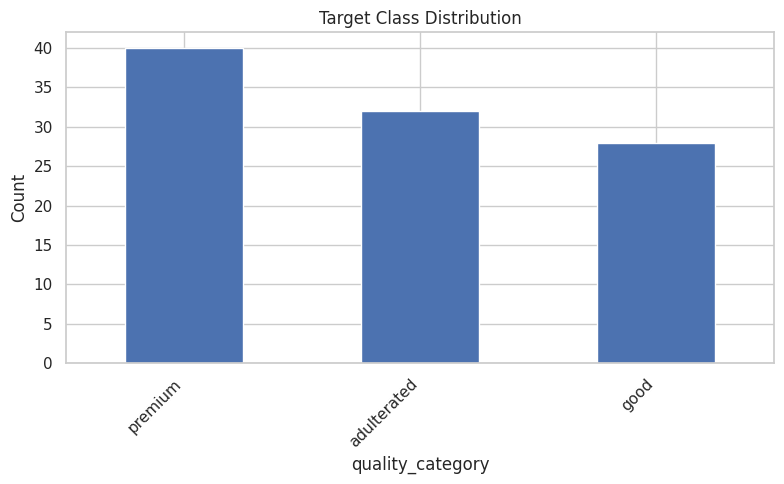

In [19]:
target_series = df_clean[TARGET_COLUMN]

print("Target column:", TARGET_COLUMN)
print("Target dtype:", target_series.dtype)
print("Unique target values:", target_series.nunique())
display(target_series.value_counts().head(20))

plt.figure(figsize=(8, 5))

if pd.api.types.is_numeric_dtype(target_series) and target_series.nunique() > 10:
    sns.histplot(target_series, kde=True)
    plt.title("Target Distribution")
    plt.xlabel(TARGET_COLUMN)
else:
    target_series.value_counts().plot(kind="bar")
    plt.title("Target Class Distribution")
    plt.xlabel(TARGET_COLUMN)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

18. Numerical feature distributions

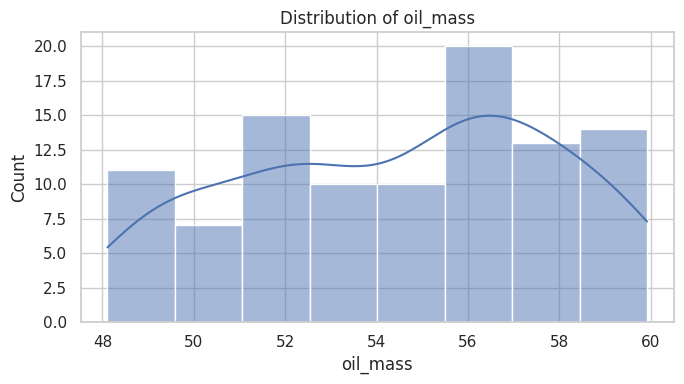

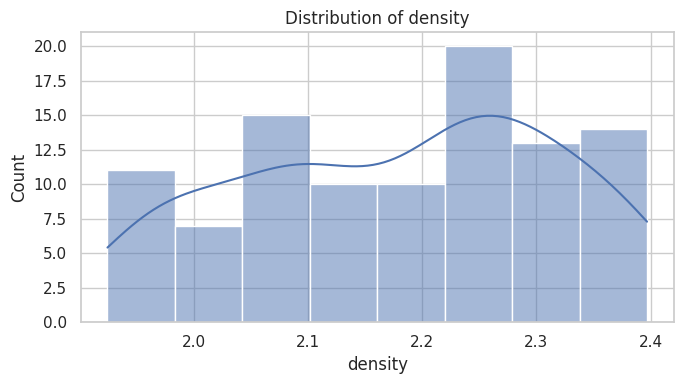

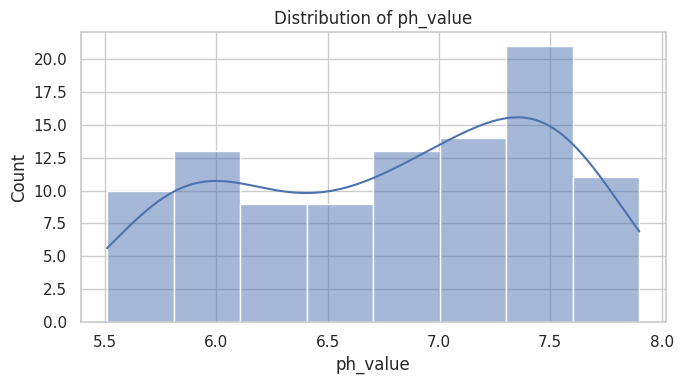

In [21]:
if len(numerical_features) == 0:
    print("No numerical features found.")
else:
    for col in numerical_features:
        plt.figure(figsize=(7, 4))
        sns.histplot(df_clean[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

19. Categorical feature distributions

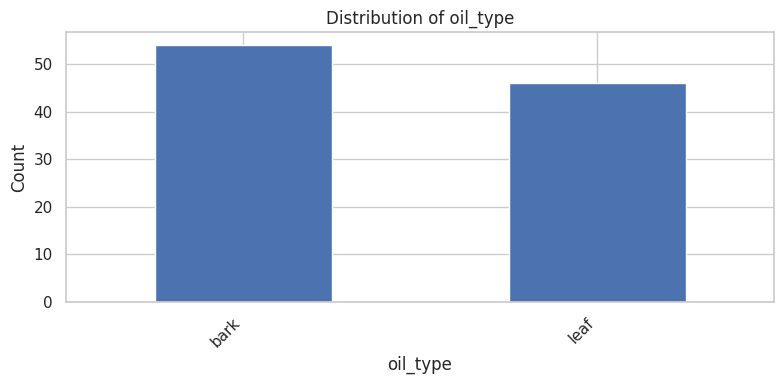

In [22]:
if len(categorical_features) == 0:
    print("No categorical features found.")
else:
    for col in categorical_features:
        plt.figure(figsize=(8, 4))
        df_clean[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

20. Correlation heatmap

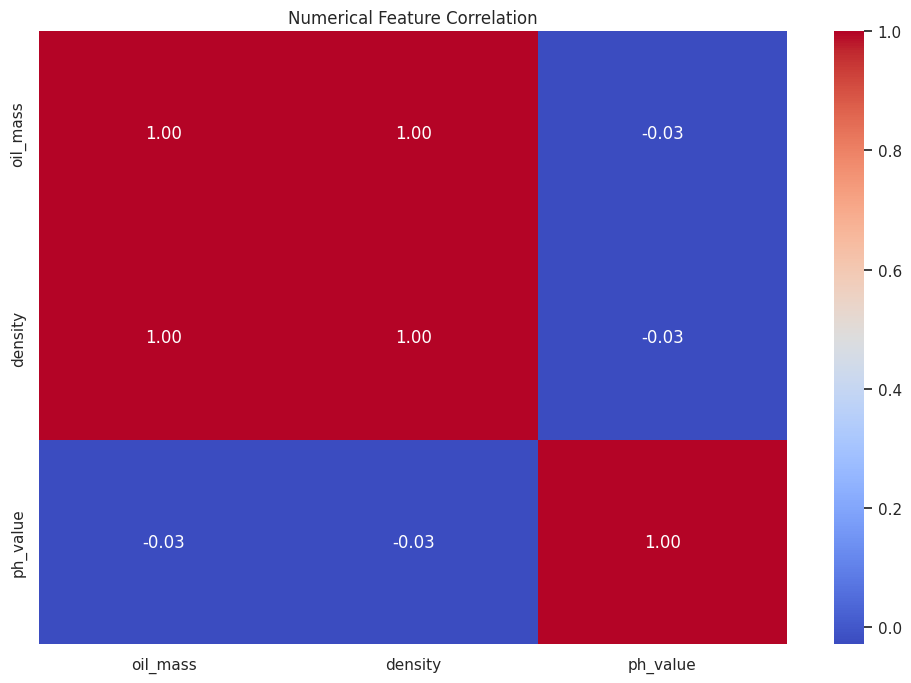

In [23]:
if len(numerical_features) > 1:
    plt.figure(figsize=(10, 7))
    corr = df_clean[numerical_features].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Numerical Feature Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical features for correlation heatmap.")

21. Image preview grid

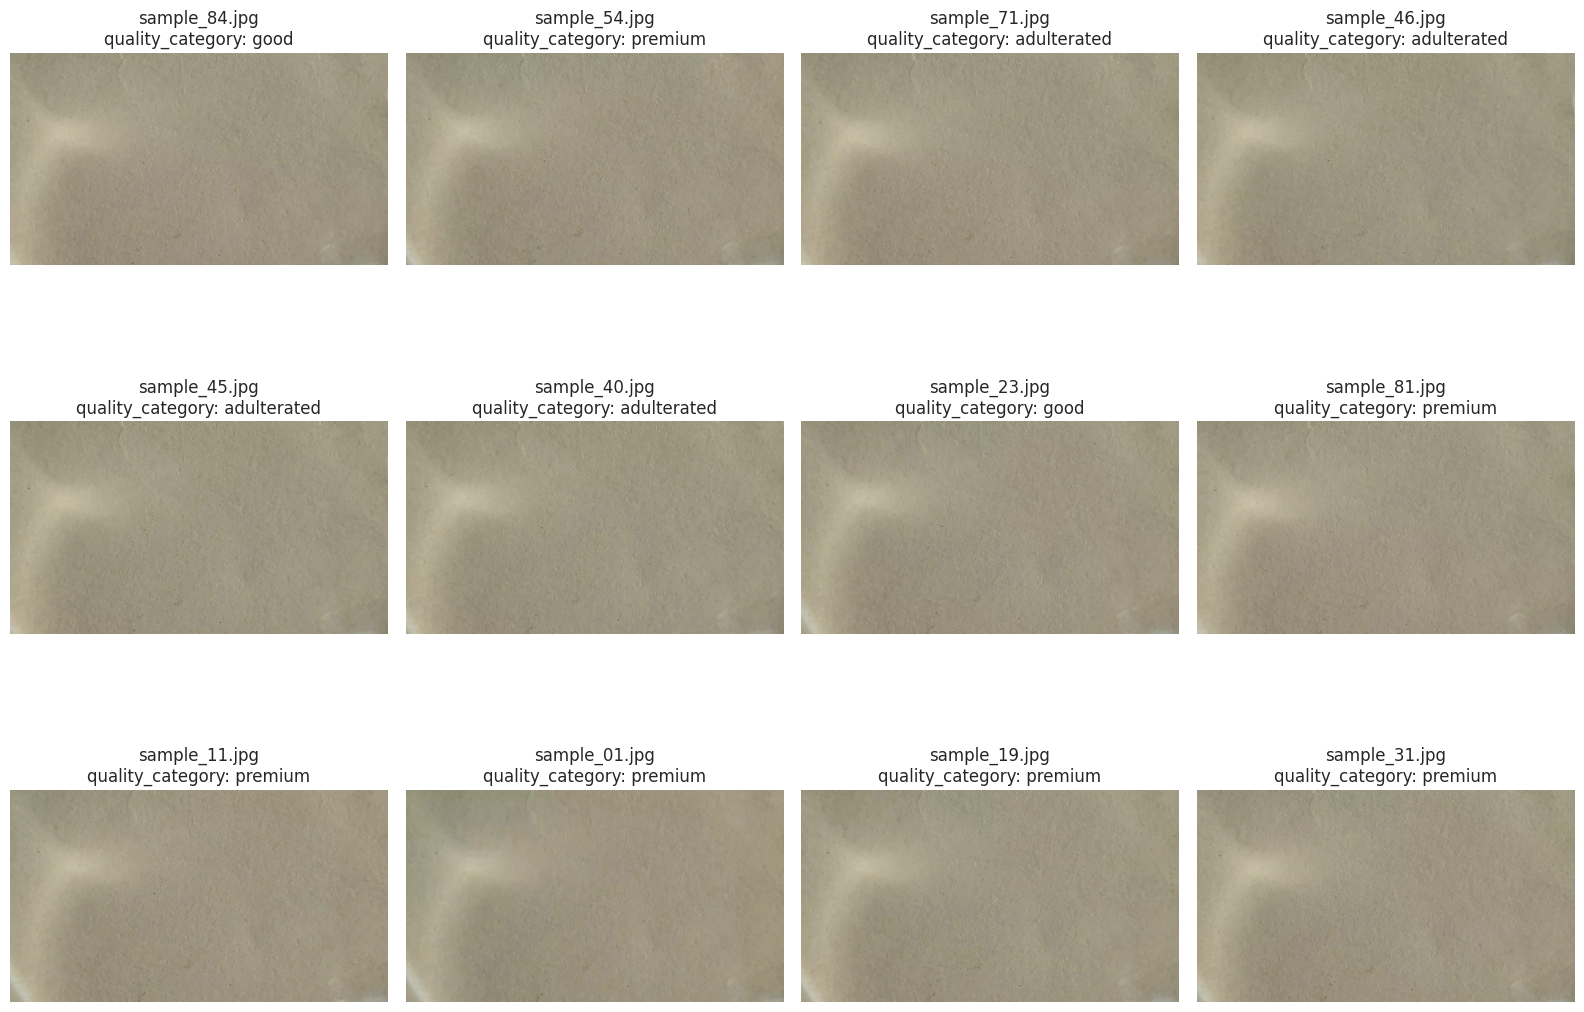

In [24]:
def show_image_grid(dataframe, rows=3, cols=4):
    sample_df = dataframe.sample(
        min(rows * cols, len(dataframe)),
        random_state=RANDOM_STATE
    )

    plt.figure(figsize=(cols * 4, rows * 4))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img_path = row["image_path"]

        try:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{os.path.basename(img_path)}\n{TARGET_COLUMN}: {row[TARGET_COLUMN]}")
        except Exception as e:
            print("Could not load image:", img_path, e)

    plt.tight_layout()
    plt.show()

if len(df_image_clean) > 0:
    show_image_grid(df_image_clean)
else:
    print("No valid images found for preview.")

**Problem Type Detection**


22. Detect regression or classification

In [25]:
def detect_problem_type(series):
    unique_count = series.nunique()
    total_count = len(series)

    if pd.api.types.is_numeric_dtype(series):
        unique_ratio = unique_count / total_count

        if unique_count > 10 and unique_ratio > 0.1:
            return "regression"
        else:
            return "classification"
    else:
        return "classification"

PROBLEM_TYPE = detect_problem_type(df_clean[TARGET_COLUMN])

print("Detected problem type:", PROBLEM_TYPE)

Detected problem type: classification


**Tabular Model Training**


23. Prepare tabular data

In [26]:
if len(numerical_features + categorical_features) == 0:
    raise ValueError("No valid tabular features found after leakage prevention.")

X_tabular = df_clean[numerical_features + categorical_features].copy()
y = df_clean[TARGET_COLUMN].copy()

if PROBLEM_TYPE == "classification":
    label_encoder = LabelEncoder()
    y_model = label_encoder.fit_transform(y.astype(str))

    joblib.dump(label_encoder, os.path.join(MODEL_DIR, "label_encoder.pkl"))

    print("Classes:", list(label_encoder.classes_))
else:
    label_encoder = None
    y_model = y.astype(float).values

if PROBLEM_TYPE == "classification" and len(np.unique(y_model)) > 1:
    stratify_value = y_model
else:
    stratify_value = None

X_train_tab, X_val_tab, y_train, y_val = train_test_split(
    X_tabular,
    y_model,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_value
)

print("Train shape:", X_train_tab.shape)
print("Validation shape:", X_val_tab.shape)

Classes: ['adulterated', 'good', 'premium']
Train shape: (80, 4)
Validation shape: (20, 4)


24. Preprocessing pipeline

In [27]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

metadata = {
    "target_column": TARGET_COLUMN,
    "image_column": image_column,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "problem_type": PROBLEM_TYPE
}

joblib.dump(metadata, os.path.join(MODEL_DIR, "metadata.pkl"))

print("Metadata saved.")

Metadata saved.


25. Evaluation helper functions

In [28]:
def evaluate_regression(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Regression Evaluation")
    print("-" * 50)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R²:", r2)

    return {
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }


def evaluate_classification(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{model_name} Classification Evaluation")
    print("-" * 50)
    print("Accuracy:", acc)
    print("Weighted F1:", f1)

    if label_encoder is not None:
        target_names = label_encoder.classes_
    else:
        target_names = None

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "accuracy": acc,
        "f1": f1
    }


def plot_regression_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_true, y=y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: Predicted vs Actual")

    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot([min_val, max_val], [min_val, max_val], "r--")
    plt.tight_layout()
    plt.show()

    residuals = y_true - y_pred

    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}: Residual Plot")
    plt.tight_layout()
    plt.show()

26. Train RandomForest, XGBoost, CatBoost


Training RandomForest...

RandomForest Classification Evaluation
--------------------------------------------------
Accuracy: 0.15
Weighted F1: 0.1282051282051282

Classification Report:
              precision    recall  f1-score   support

 adulterated       0.17      0.33      0.22         6
        good       0.00      0.00      0.00         6
     premium       0.20      0.12      0.15         8

    accuracy                           0.15        20
   macro avg       0.12      0.15      0.13        20
weighted avg       0.13      0.15      0.13        20



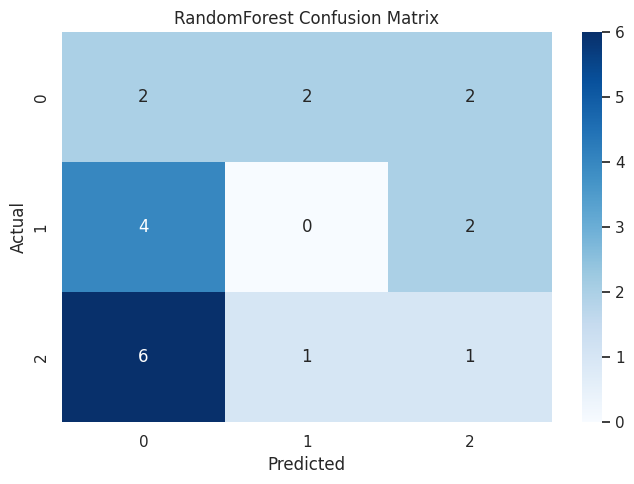


Training XGBoost...

XGBoost Classification Evaluation
--------------------------------------------------
Accuracy: 0.2
Weighted F1: 0.19153846153846155

Classification Report:
              precision    recall  f1-score   support

 adulterated       0.22      0.33      0.27         6
        good       0.17      0.17      0.17         6
     premium       0.20      0.12      0.15         8

    accuracy                           0.20        20
   macro avg       0.20      0.21      0.20        20
weighted avg       0.20      0.20      0.19        20



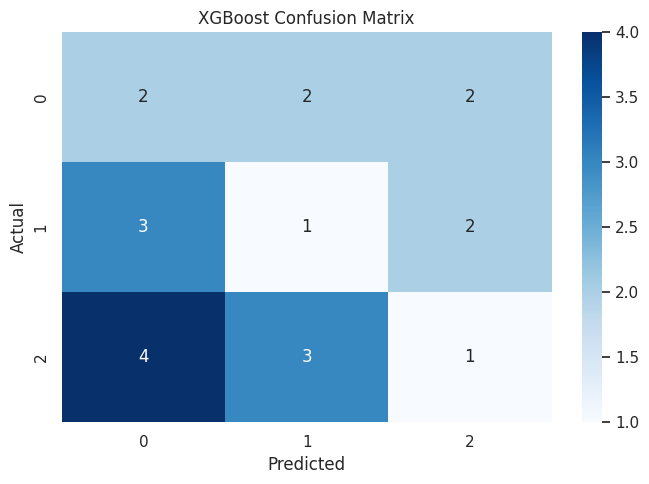


Training CatBoost...

CatBoost Classification Evaluation
--------------------------------------------------
Accuracy: 0.4
Weighted F1: 0.38293650793650796

Classification Report:
              precision    recall  f1-score   support

 adulterated       0.25      0.33      0.29         6
        good       0.50      0.17      0.25         6
     premium       0.50      0.62      0.56         8

    accuracy                           0.40        20
   macro avg       0.42      0.38      0.36        20
weighted avg       0.42      0.40      0.38        20



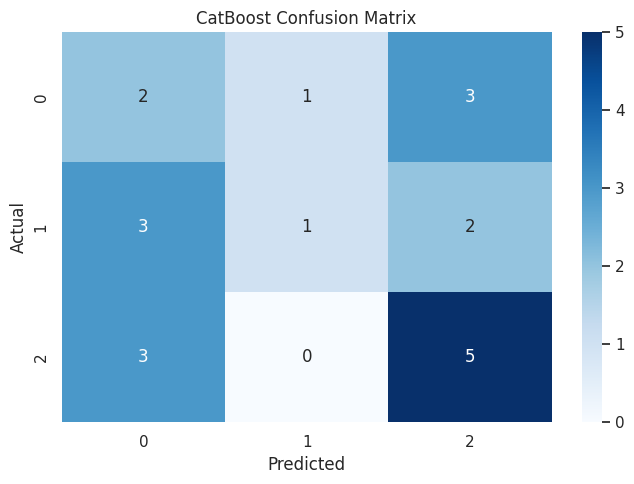

,model,accuracy,f1
0,RandomForest,0.15,0.128205
1,XGBoost,0.20,0.191538
2,CatBoost,0.40,0.382937


In [29]:
tabular_results = []
trained_tabular_models = {}

if PROBLEM_TYPE == "regression":
    models_to_train = {
        "RandomForest": RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "XGBoost": XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            objective="reg:squarederror"
        ),
        "CatBoost": CatBoostRegressor(
            iterations=300,
            learning_rate=0.03,
            depth=5,
            loss_function="RMSE",
            random_seed=RANDOM_STATE,
            verbose=False
        )
    }

else:
    num_classes = len(np.unique(y_train))

    if num_classes == 2:
        xgb_objective = "binary:logistic"
        xgb_eval_metric = "logloss"
    else:
        xgb_objective = "multi:softprob"
        xgb_eval_metric = "mlogloss"

    models_to_train = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            objective=xgb_objective,
            eval_metric=xgb_eval_metric
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300,
            learning_rate=0.03,
            depth=5,
            loss_function="Logloss" if num_classes == 2 else "MultiClass",
            random_seed=RANDOM_STATE,
            verbose=False
        )
    }

for model_name, base_model in models_to_train.items():
    print(f"\nTraining {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", base_model)
        ]
    )

    pipeline.fit(X_train_tab, y_train)
    y_pred = pipeline.predict(X_val_tab)

    if PROBLEM_TYPE == "regression":
        result = evaluate_regression(y_val, y_pred, model_name)
        plot_regression_predictions(y_val, y_pred, model_name)
    else:
        result = evaluate_classification(y_val, y_pred, model_name)

    tabular_results.append(result)
    trained_tabular_models[model_name] = pipeline

results_df = pd.DataFrame(tabular_results)
display(results_df)

27. Select best tabular model

In [30]:
if PROBLEM_TYPE == "regression":
    best_row = results_df.sort_values("rmse", ascending=True).iloc[0]
else:
    best_row = results_df.sort_values("f1", ascending=False).iloc[0]

best_tabular_model_name = best_row["model"]
best_tabular_model = trained_tabular_models[best_tabular_model_name]

print("Best tabular model:", best_tabular_model_name)

joblib.dump(best_tabular_model, os.path.join(MODEL_DIR, "best_tabular_model.pkl"))
print("Saved best tabular model.")

Best tabular model: CatBoost
Saved best tabular model.


28. Feature importance

,feature,importance
2,ph_value,40.233817
1,density,23.279313
0,oil_mass,20.521558
4,oil_type_leaf,8.193090
3,oil_type_bark,7.772222


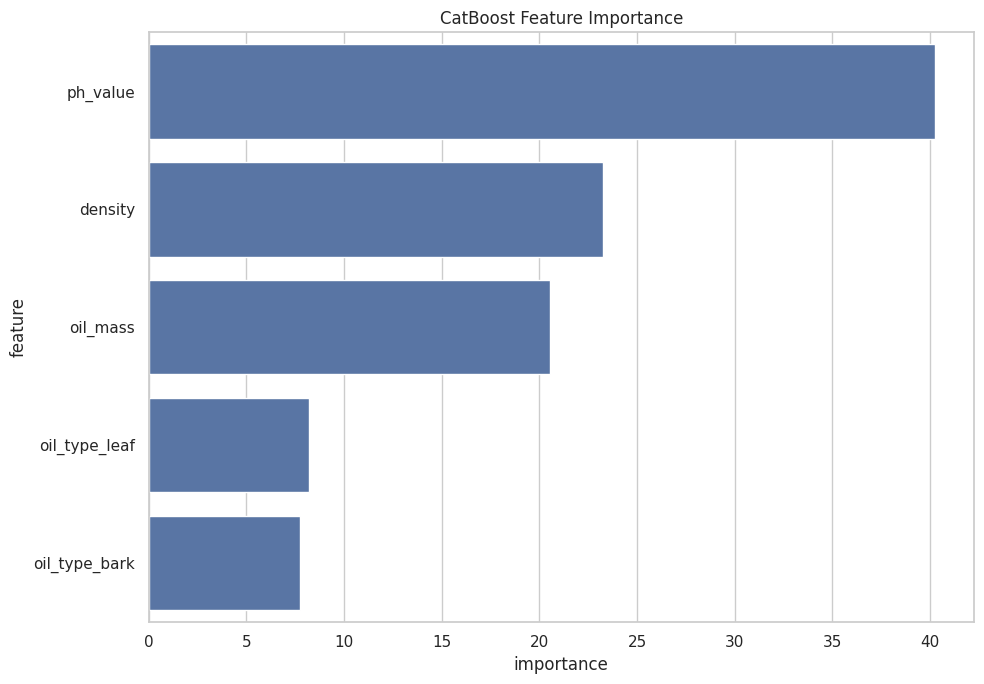

In [31]:
def get_feature_names_from_preprocessor(fitted_preprocessor):
    feature_names = []

    if len(numerical_features) > 0:
        feature_names.extend(numerical_features)

    if len(categorical_features) > 0:
        onehot = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features)
        feature_names.extend(cat_names)

    return feature_names

try:
    fitted_preprocessor = best_tabular_model.named_steps["preprocessor"]
    fitted_model = best_tabular_model.named_steps["model"]

    feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)

    if hasattr(fitted_model, "feature_importances_"):
        importances = fitted_model.feature_importances_

        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        display(importance_df.head(30))

        plt.figure(figsize=(10, 7))
        sns.barplot(
            data=importance_df.head(20),
            x="importance",
            y="feature"
        )
        plt.title(f"{best_tabular_model_name} Feature Importance")
        plt.tight_layout()
        plt.show()
    else:
        print("Model does not support feature_importances_.")
except Exception as e:
    print("Could not generate feature importance:", e)

**Image Model**


29. Prepare image model data

In [32]:
USE_IMAGE_MODEL = len(df_image_clean) >= 20

print("Use image model:", USE_IMAGE_MODEL)

if USE_IMAGE_MODEL:
    image_df = df_image_clean.copy()

    if PROBLEM_TYPE == "classification":
        image_df["target_encoded"] = label_encoder.transform(image_df[TARGET_COLUMN].astype(str))
        image_target = image_df["target_encoded"].values
    else:
        image_target = image_df[TARGET_COLUMN].astype(float).values

    if PROBLEM_TYPE == "classification" and len(np.unique(image_target)) > 1:
        image_stratify = image_target
    else:
        image_stratify = None

    train_img_df, val_img_df = train_test_split(
        image_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=image_stratify
    )

    print("Image train shape:", train_img_df.shape)
    print("Image validation shape:", val_img_df.shape)
else:
    print("Not enough valid images. Image model will be skipped.")

Use image model: True
Image train shape: (80, 11)
Image validation shape: (20, 11)


30. Create image datasets

In [33]:
def load_and_preprocess_image(path, target):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, target


def create_image_dataset(dataframe, shuffle=True):
    paths = dataframe["image_path"].values

    if PROBLEM_TYPE == "classification":
        targets = dataframe["target_encoded"].values
    else:
        targets = dataframe[TARGET_COLUMN].astype(float).values

    dataset = tf.data.Dataset.from_tensor_slices((paths, targets))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=RANDOM_STATE)

    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

if USE_IMAGE_MODEL:
    train_img_ds = create_image_dataset(train_img_df, shuffle=True)
    val_img_ds = create_image_dataset(val_img_df, shuffle=False)

31. Build image model

In [34]:
def build_image_model():
    augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = augmentation(inputs)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)

    if PROBLEM_TYPE == "regression":
        outputs = layers.Dense(1, activation="linear")(x)
        loss = "mse"
        metrics = [
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    else:
        num_classes = len(label_encoder.classes_)

        if num_classes == 2:
            outputs = layers.Dense(1, activation="sigmoid")(x)
            loss = "binary_crossentropy"
            metrics = ["accuracy"]
        else:
            outputs = layers.Dense(num_classes, activation="softmax")(x)
            loss = "sparse_categorical_crossentropy"
            metrics = ["accuracy"]

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss=loss,
        metrics=metrics
    )

    return model

if USE_IMAGE_MODEL:
    image_model = build_image_model()
    image_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,438 (16.08 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

32. Train image model

In [35]:
if USE_IMAGE_MODEL:
    image_model_path = os.path.join(MODEL_DIR, "best_image_model.keras")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            image_model_path,
            monitor="val_loss",
            save_best_only=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7
        )
    ]

    image_history = image_model.fit(
        train_img_ds,
        validation_data=val_img_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    image_model = tf.keras.models.load_model(image_model_path)
else:
    image_history = None

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.4000 - loss: 1.4992 - val_accuracy: 0.3000 - val_loss: 1.1272 - learning_rate: 3.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3125 - loss: 1.5720 - val_accuracy: 0.3000 - val_loss: 1.1145 - learning_rate: 3.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3250 - loss: 1.5914 - val_accuracy: 0.3000 - val_loss: 1.1142 - learning_rate: 3.0000e-04
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2500 - loss: 1.5919 - val_accuracy: 0.3000 - val_loss: 1.1234 - learning_rate: 3.0000e-04
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3375 - loss: 1.5348 - val_accuracy: 0.3000 - val_loss: 1.1279 - learning_rate: 3.0000e-04
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.3750 - loss: 1.5045 - val_accuracy: 0.3000 - val_loss: 1.1209 - learning_rate: 3.0000e-04
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3250 - loss:

33. Plot training curves

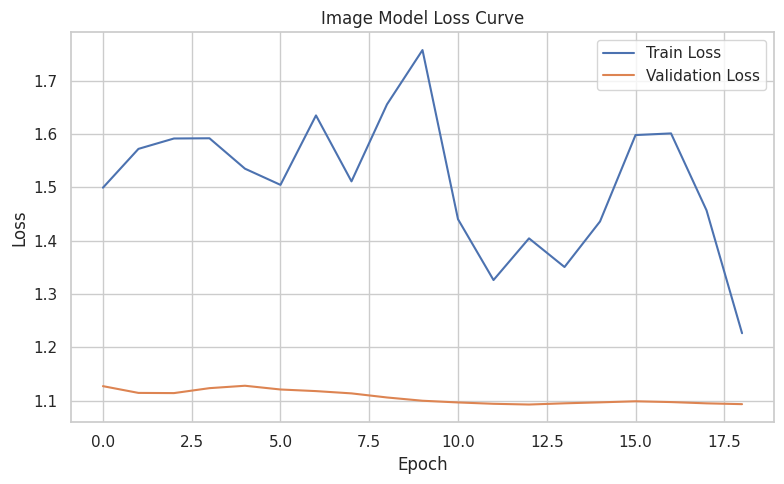

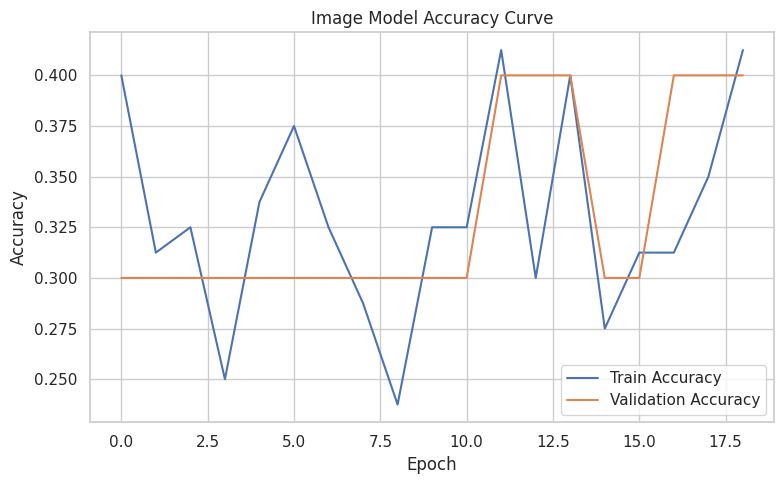

In [36]:
def plot_training_history(history, title_prefix):
    if history is None:
        return

    history_dict = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "accuracy" in history_dict:
        plt.figure(figsize=(8, 5))
        plt.plot(history_dict["accuracy"], label="Train Accuracy")
        plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
        plt.title(f"{title_prefix} Accuracy Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if "mae" in history_dict:
        plt.figure(figsize=(8, 5))
        plt.plot(history_dict["mae"], label="Train MAE")
        plt.plot(history_dict["val_mae"], label="Validation MAE")
        plt.title(f"{title_prefix} MAE Curve")
        plt.xlabel("Epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_training_history(image_history, "Image Model")

34. Evaluate image model

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step

Image Model Classification Evaluation
--------------------------------------------------
Accuracy: 0.4
Weighted F1: 0.22857142857142856

Classification Report:
              precision    recall  f1-score   support

 adulterated       0.00      0.00      0.00         6
        good       0.00      0.00      0.00         6
     premium       0.40      1.00      0.57         8

    accuracy                           0.40        20
   macro avg       0.13      0.33      0.19        20
weighted avg       0.16      0.40      0.23        20



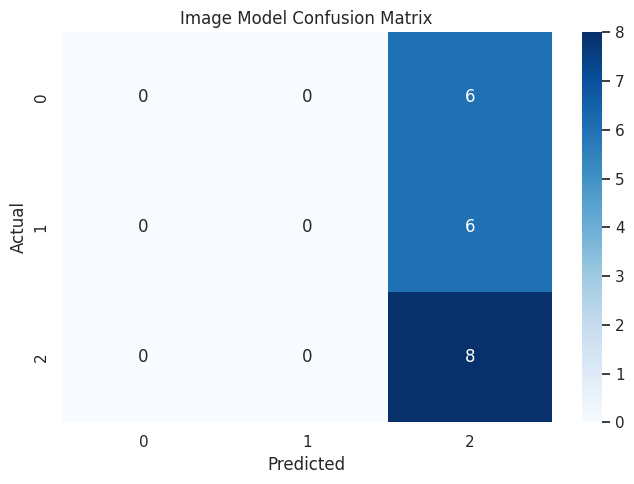

In [37]:
image_result = None

if USE_IMAGE_MODEL:
    y_val_image_true = (
        val_img_df["target_encoded"].values
        if PROBLEM_TYPE == "classification"
        else val_img_df[TARGET_COLUMN].astype(float).values
    )

    image_preds_raw = image_model.predict(val_img_ds)

    if PROBLEM_TYPE == "regression":
        image_preds = image_preds_raw.flatten()
        image_result = evaluate_regression(y_val_image_true, image_preds, "Image Model")
        plot_regression_predictions(y_val_image_true, image_preds, "Image Model")
    else:
        num_classes = len(label_encoder.classes_)

        if num_classes == 2:
            image_preds = (image_preds_raw.flatten() >= 0.5).astype(int)
        else:
            image_preds = np.argmax(image_preds_raw, axis=1)

        image_result = evaluate_classification(y_val_image_true, image_preds, "Image Model")
else:
    print("Image model skipped.")

**Hybrid Model**


35. Prepare hybrid model

In [38]:
USE_HYBRID_MODEL = USE_IMAGE_MODEL and len(numerical_features + categorical_features) > 0

print("Use hybrid model:", USE_HYBRID_MODEL)

if USE_HYBRID_MODEL:
    hybrid_df = df_image_clean.copy()

    if PROBLEM_TYPE == "classification":
        hybrid_df["target_encoded"] = label_encoder.transform(hybrid_df[TARGET_COLUMN].astype(str))
        hybrid_target = hybrid_df["target_encoded"].values
    else:
        hybrid_target = hybrid_df[TARGET_COLUMN].astype(float).values

    if PROBLEM_TYPE == "classification" and len(np.unique(hybrid_target)) > 1:
        hybrid_stratify = hybrid_target
    else:
        hybrid_stratify = None

    train_hybrid_df, val_hybrid_df = train_test_split(
        hybrid_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=hybrid_stratify
    )

    hybrid_preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    X_train_hybrid_tab = hybrid_preprocessor.fit_transform(
        train_hybrid_df[numerical_features + categorical_features]
    )

    X_val_hybrid_tab = hybrid_preprocessor.transform(
        val_hybrid_df[numerical_features + categorical_features]
    )

    if hasattr(X_train_hybrid_tab, "toarray"):
        X_train_hybrid_tab = X_train_hybrid_tab.toarray()
        X_val_hybrid_tab = X_val_hybrid_tab.toarray()

    X_train_hybrid_tab = X_train_hybrid_tab.astype(np.float32)
    X_val_hybrid_tab = X_val_hybrid_tab.astype(np.float32)

    joblib.dump(
        hybrid_preprocessor,
        os.path.join(MODEL_DIR, "hybrid_tabular_preprocessor.pkl")
    )

    print("Hybrid tabular train shape:", X_train_hybrid_tab.shape)
    print("Hybrid tabular validation shape:", X_val_hybrid_tab.shape)

Use hybrid model: True
Hybrid tabular train shape: (80, 5)
Hybrid tabular validation shape: (20, 5)


36. Load images as arrays for hybrid model

In [39]:
def load_image_array(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img).astype(np.float32) / 255.0
    return img


def load_image_arrays(paths):
    return np.array([load_image_array(path) for path in paths], dtype=np.float32)

if USE_HYBRID_MODEL:
    X_train_hybrid_img = load_image_arrays(train_hybrid_df["image_path"].values)
    X_val_hybrid_img = load_image_arrays(val_hybrid_df["image_path"].values)

    if PROBLEM_TYPE == "classification":
        y_train_hybrid = train_hybrid_df["target_encoded"].values
        y_val_hybrid = val_hybrid_df["target_encoded"].values
    else:
        y_train_hybrid = train_hybrid_df[TARGET_COLUMN].astype(float).values
        y_val_hybrid = val_hybrid_df[TARGET_COLUMN].astype(float).values

    print("Hybrid image train shape:", X_train_hybrid_img.shape)
    print("Hybrid image validation shape:", X_val_hybrid_img.shape)

Hybrid image train shape: (80, 224, 224, 3)
Hybrid image validation shape: (20, 224, 224, 3)


37. Build hybrid model

In [40]:
def build_hybrid_model(tabular_input_dim):
    image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")

    augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    x_img = augmentation(image_input)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    x_img = base_model(x_img, training=False)
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dropout(0.35)(x_img)
    x_img = layers.Dense(128, activation="relu")(x_img)
    x_img = layers.BatchNormalization()(x_img)

    tabular_input = layers.Input(shape=(tabular_input_dim,), name="tabular_input")

    x_tab = layers.Dense(64, activation="relu")(tabular_input)
    x_tab = layers.BatchNormalization()(x_tab)
    x_tab = layers.Dropout(0.25)(x_tab)
    x_tab = layers.Dense(32, activation="relu")(x_tab)

    combined = layers.concatenate([x_img, x_tab])

    x = layers.Dense(128, activation="relu")(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    if PROBLEM_TYPE == "regression":
        output = layers.Dense(1, activation="linear")(x)
        loss = "mse"
        metrics = [
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    else:
        num_classes = len(label_encoder.classes_)

        if num_classes == 2:
            output = layers.Dense(1, activation="sigmoid")(x)
            loss = "binary_crossentropy"
            metrics = ["accuracy"]
        else:
            output = layers.Dense(num_classes, activation="softmax")(x)
            loss = "sparse_categorical_crossentropy"
            metrics = ["accuracy"]

    model = models.Model(
        inputs=[image_input, tabular_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss=loss,
        metrics=metrics
    )

    return model

if USE_HYBRID_MODEL:
    hybrid_model = build_hybrid_model(X_train_hybrid_tab.shape[1])
    hybrid_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ sequential_1[0][… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │        384 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │        195 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,246,342 (16.20 MB)

 Trainable params: 196,131 (766.14 KB)

 Non-trainable params: 4,050,211 (15.45 MB)

38. Train hybrid model

In [41]:
if USE_HYBRID_MODEL:
    hybrid_model_path = os.path.join(MODEL_DIR, "best_hybrid_model.keras")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            hybrid_model_path,
            monitor="val_loss",
            save_best_only=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7
        )
    ]

    hybrid_history = hybrid_model.fit(
        [X_train_hybrid_img, X_train_hybrid_tab],
        y_train_hybrid,
        validation_data=(
            [X_val_hybrid_img, X_val_hybrid_tab],
            y_val_hybrid
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    hybrid_model = tf.keras.models.load_model(hybrid_model_path)
else:
    hybrid_history = None

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.2500 - loss: 2.3358 - val_accuracy: 0.3000 - val_loss: 1.1193 - learning_rate: 3.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3375 - loss: 1.9006 - val_accuracy: 0.3000 - val_loss: 1.1149 - learning_rate: 3.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2875 - loss: 1.7036 - val_accuracy: 0.3000 - val_loss: 1.1108 - learning_rate: 3.0000e-04
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2000 - loss: 1.8869 - val_accuracy: 0.3500 - val_loss: 1.1079 - learning_rate: 3.0000e-04
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2750 - loss: 1.8646 - val_accuracy: 0.4500 - val_loss: 1.0967 - learning_rate: 3.0000e-04
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3875 - loss: 1.5688 - val_accuracy: 0.4500 - val_loss: 1.0913 - learning_rate: 3.0000e-04
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4125 - loss:

39. Plot hybrid training curves

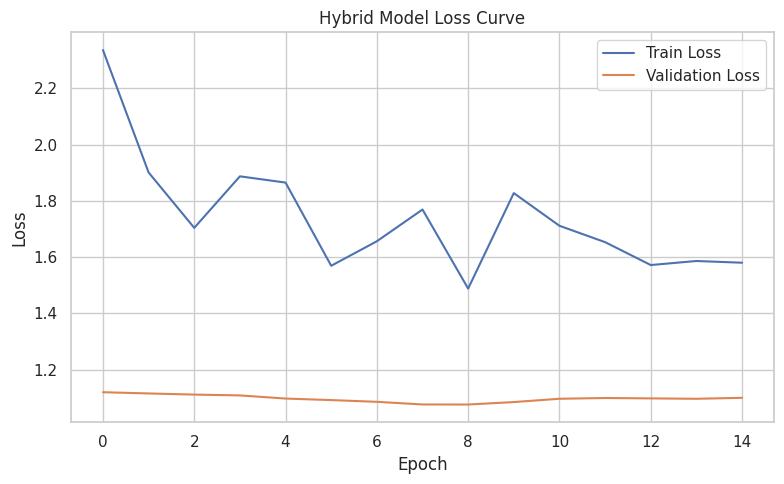

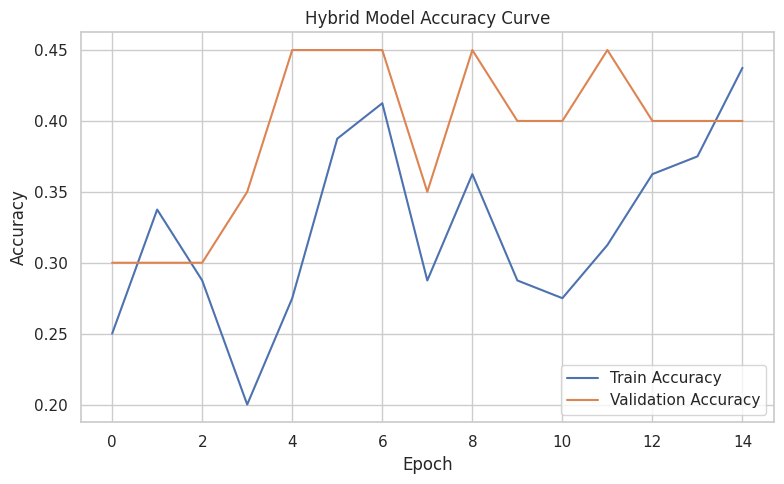

In [42]:
plot_training_history(hybrid_history, "Hybrid Model")

40. Evaluate hybrid model

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

Hybrid Model Classification Evaluation
--------------------------------------------------
Accuracy: 0.45
Weighted F1: 0.32275132275132273

Classification Report:
              precision    recall  f1-score   support

 adulterated       1.00      0.17      0.29         6
        good       0.00      0.00      0.00         6
     premium       0.42      1.00      0.59         8

    accuracy                           0.45        20
   macro avg       0.47      0.39      0.29        20
weighted avg       0.47      0.45      0.32        20



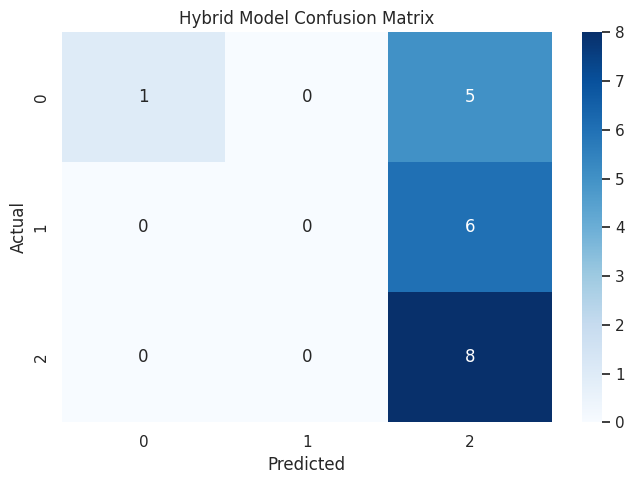

In [43]:
hybrid_result = None

if USE_HYBRID_MODEL:
    hybrid_preds_raw = hybrid_model.predict([X_val_hybrid_img, X_val_hybrid_tab])

    if PROBLEM_TYPE == "regression":
        hybrid_preds = hybrid_preds_raw.flatten()
        hybrid_result = evaluate_regression(y_val_hybrid, hybrid_preds, "Hybrid Model")
        plot_regression_predictions(y_val_hybrid, hybrid_preds, "Hybrid Model")
    else:
        num_classes = len(label_encoder.classes_)

        if num_classes == 2:
            hybrid_preds = (hybrid_preds_raw.flatten() >= 0.5).astype(int)
        else:
            hybrid_preds = np.argmax(hybrid_preds_raw, axis=1)

        hybrid_result = evaluate_classification(y_val_hybrid, hybrid_preds, "Hybrid Model")
else:
    print("Hybrid model skipped.")

**Compare and Save**


41. Compare all models

In [44]:
all_results = []

for result in tabular_results:
    all_results.append(result)

if image_result is not None:
    all_results.append(image_result)

if hybrid_result is not None:
    all_results.append(hybrid_result)

comparison_df = pd.DataFrame(all_results)

print("Model comparison:")
display(comparison_df)

if PROBLEM_TYPE == "regression":
    comparison_df_sorted = comparison_df.sort_values("rmse", ascending=True)
else:
    comparison_df_sorted = comparison_df.sort_values("f1", ascending=False)

display(comparison_df_sorted)

best_overall_model_name = comparison_df_sorted.iloc[0]["model"]

print("Best overall model:", best_overall_model_name)

Model comparison:


,model,accuracy,f1
0,RandomForest,0.15,0.128205
1,XGBoost,0.20,0.191538
2,CatBoost,0.40,0.382937
3,Image Model,0.40,0.228571
4,Hybrid Model,0.45,0.322751


,model,accuracy,f1
2,CatBoost,0.40,0.382937
4,Hybrid Model,0.45,0.322751
3,Image Model,0.40,0.228571
1,XGBoost,0.20,0.191538
0,RandomForest,0.15,0.128205


Best overall model: CatBoost


42. Save final model

In [45]:
final_model_info = {
    "problem_type": PROBLEM_TYPE,
    "target_column": TARGET_COLUMN,
    "image_column": image_column,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "best_model_name": best_overall_model_name
}

with open(os.path.join(MODEL_DIR, "final_model_info.json"), "w") as f:
    json.dump(final_model_info, f, indent=4)

if best_overall_model_name in trained_tabular_models:
    final_model = trained_tabular_models[best_overall_model_name]
    joblib.dump(final_model, os.path.join(MODEL_DIR, "final_model.pkl"))
    print("Saved final tabular model: /content/models/final_model.pkl")

elif best_overall_model_name == "Image Model":
    image_model.save(os.path.join(MODEL_DIR, "final_model.keras"))
    print("Saved final image model: /content/models/final_model.keras")

elif best_overall_model_name == "Hybrid Model":
    hybrid_model.save(os.path.join(MODEL_DIR, "final_model.keras"))
    print("Saved final hybrid model: /content/models/final_model.keras")

print("Saved final model info: /content/models/final_model_info.json")

Saved final tabular model: /content/models/final_model.pkl
Saved final model info: /content/models/final_model_info.json


43. Save predictions.csv

In [46]:
predictions_output = pd.DataFrame()

if best_overall_model_name in trained_tabular_models:
    final_model = trained_tabular_models[best_overall_model_name]
    final_preds = final_model.predict(X_val_tab)

    predictions_output = X_val_tab.copy()
    predictions_output["actual"] = y_val
    predictions_output["predicted"] = final_preds

    if PROBLEM_TYPE == "classification" and label_encoder is not None:
        predictions_output["actual_label"] = label_encoder.inverse_transform(y_val.astype(int))
        predictions_output["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))

elif best_overall_model_name == "Image Model":
    final_preds_raw = image_model.predict(val_img_ds)

    if PROBLEM_TYPE == "regression":
        final_preds = final_preds_raw.flatten()
    else:
        if len(label_encoder.classes_) == 2:
            final_preds = (final_preds_raw.flatten() >= 0.5).astype(int)
        else:
            final_preds = np.argmax(final_preds_raw, axis=1)

    predictions_output = val_img_df.copy()
    predictions_output["actual"] = y_val_image_true
    predictions_output["predicted"] = final_preds

    if PROBLEM_TYPE == "classification":
        predictions_output["actual_label"] = label_encoder.inverse_transform(y_val_image_true.astype(int))
        predictions_output["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))

elif best_overall_model_name == "Hybrid Model":
    final_preds_raw = hybrid_model.predict([X_val_hybrid_img, X_val_hybrid_tab])

    if PROBLEM_TYPE == "regression":
        final_preds = final_preds_raw.flatten()
    else:
        if len(label_encoder.classes_) == 2:
            final_preds = (final_preds_raw.flatten() >= 0.5).astype(int)
        else:
            final_preds = np.argmax(final_preds_raw, axis=1)

    predictions_output = val_hybrid_df.copy()
    predictions_output["actual"] = y_val_hybrid
    predictions_output["predicted"] = final_preds

    if PROBLEM_TYPE == "classification":
        predictions_output["actual_label"] = label_encoder.inverse_transform(y_val_hybrid.astype(int))
        predictions_output["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))

predictions_path = os.path.join(OUTPUT_DIR, "predictions.csv")
predictions_output.to_csv(predictions_path, index=False)

print("Saved predictions:", predictions_path)
display(predictions_output.head())

Saved predictions: /content/outputs/predictions.csv


,oil_mass,density,ph_value,oil_type,actual,predicted,actual_label,predicted_label
10,52.51,2.1004,5.92,bark,2,2,premium,premium
3,50.02,2.0008,6.35,bark,2,0,premium,adulterated
23,52.36,2.0944,7.25,bark,2,2,premium,premium
46,56.09,2.2436,7.84,leaf,2,2,premium,premium
43,59.68,2.3872,6.77,bark,1,1,good,good


44. Final prediction function

In [47]:
predictions_output = pd.DataFrame()

if best_overall_model_name in trained_tabular_models:
    final_model = trained_tabular_models[best_overall_model_name]
    final_preds = final_model.predict(X_val_tab)

    predictions_output = X_val_tab.copy()
    predictions_output["actual"] = y_val
    predictions_output["predicted"] = final_preds

    if PROBLEM_TYPE == "classification" and label_encoder is not None:
        predictions_output["actual_label"] = label_encoder.inverse_transform(y_val.astype(int))
        predictions_output["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))

elif best_overall_model_name == "Image Model":
    final_preds_raw = image_model.predict(val_img_ds)

    if PROBLEM_TYPE == "regression":
        final_preds = final_preds_raw.flatten()
    else:
        if len(label_encoder.classes_) == 2:
            final_preds = (final_preds_raw.flatten() >= 0.5).astype(int)
        else:
            final_preds = np.argmax(final_preds_raw, axis=1)

    predictions_output = val_img_df.copy()
    predictions_output["actual"] = y_val_image_true
    predictions_output["predicted"] = final_preds

    if PROBLEM_TYPE == "classification":
        predictions_output["actual_label"] = label_encoder.inverse_transform(y_val_image_true.astype(int))
        predictions_output["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))

elif best_overall_model_name == "Hybrid Model":
    final_preds_raw = hybrid_model.predict([X_val_hybrid_img, X_val_hybrid_tab])

    if PROBLEM_TYPE == "regression":
        final_preds = final_preds_raw.flatten()
    else:
        if len(label_encoder.classes_) == 2:
            final_preds = (final_preds_raw.flatten() >= 0.5).astype(int)
        else:
            final_preds = np.argmax(final_preds_raw, axis=1)

    predictions_output = val_hybrid_df.copy()
    predictions_output["actual"] = y_val_hybrid
    predictions_output["predicted"] = final_preds

    if PROBLEM_TYPE == "classification":
        predictions_output["actual_label"] = label_encoder.inverse_transform(y_val_hybrid.astype(int))
        predictions_output["predicted_label"] = label_encoder.inverse_transform(final_preds.astype(int))

predictions_path = os.path.join(OUTPUT_DIR, "predictions.csv")
predictions_output.to_csv(predictions_path, index=False)

print("Saved predictions:", predictions_path)
display(predictions_output.head())

Saved predictions: /content/outputs/predictions.csv


,oil_mass,density,ph_value,oil_type,actual,predicted,actual_label,predicted_label
10,52.51,2.1004,5.92,bark,2,2,premium,premium
3,50.02,2.0008,6.35,bark,2,0,premium,adulterated
23,52.36,2.0944,7.25,bark,2,2,premium,premium
46,56.09,2.2436,7.84,leaf,2,2,premium,premium
43,59.68,2.3872,6.77,bark,1,1,good,good


45. Final Export Step


In [53]:
import os
import json
import shutil
import joblib
import pandas as pd

EXPORT_DIR = "/content/final_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

export_summary = {
    "problem_type": PROBLEM_TYPE,
    "target_column": TARGET_COLUMN,
    "image_column": image_column,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "best_overall_model": best_overall_model_name,
}

# 1. Save best tabular model
if "best_tabular_model" in globals():
    tabular_model_path = os.path.join(EXPORT_DIR, "best_tabular_model.pkl")
    joblib.dump(best_tabular_model, tabular_model_path)

    export_summary["best_tabular_model"] = {
        "name": best_tabular_model_name,
        "path": tabular_model_path
    }

    print("Saved best tabular model:")
    print(tabular_model_path)
else:
    print("best_tabular_model not found. Skipping tabular export.")


# 2. Save best image model
if "image_model" in globals() and image_model is not None:
    image_model_path = os.path.join(EXPORT_DIR, "best_image_model.keras")
    image_model.save(image_model_path)

    export_summary["best_image_model"] = {
        "name": "Image Model",
        "path": image_model_path
    }

    print("Saved best image model:")
    print(image_model_path)
else:
    print("image_model not found. Skipping image model export.")


# 3. Save best hybrid model
if "hybrid_model" in globals() and hybrid_model is not None:
    hybrid_model_path = os.path.join(EXPORT_DIR, "best_hybrid_model.keras")
    hybrid_model.save(hybrid_model_path)

    export_summary["best_hybrid_model"] = {
        "name": "Hybrid Model",
        "path": hybrid_model_path
    }

    print("Saved best hybrid model:")
    print(hybrid_model_path)
else:
    print("hybrid_model not found. Skipping hybrid model export.")


# 4. Save label encoder if classification
if PROBLEM_TYPE == "classification" and "label_encoder" in globals() and label_encoder is not None:
    label_encoder_path = os.path.join(EXPORT_DIR, "label_encoder.pkl")
    joblib.dump(label_encoder, label_encoder_path)

    export_summary["label_encoder"] = label_encoder_path

    print("Saved label encoder:")
    print(label_encoder_path)


# 5. Save tabular preprocessor
if "preprocessor" in globals():
    preprocessor_path = os.path.join(EXPORT_DIR, "tabular_preprocessor.pkl")
    joblib.dump(preprocessor, preprocessor_path)

    export_summary["tabular_preprocessor"] = preprocessor_path

    print("Saved tabular preprocessor:")
    print(preprocessor_path)


# 6. Save hybrid tabular preprocessor
if "hybrid_preprocessor" in globals():
    hybrid_preprocessor_path = os.path.join(EXPORT_DIR, "hybrid_tabular_preprocessor.pkl")
    joblib.dump(hybrid_preprocessor, hybrid_preprocessor_path)

    export_summary["hybrid_tabular_preprocessor"] = hybrid_preprocessor_path

    print("Saved hybrid tabular preprocessor:")
    print(hybrid_preprocessor_path)


# 7. Save model comparison table
if "comparison_df" in globals():
    comparison_path = os.path.join(EXPORT_DIR, "model_comparison.csv")
    comparison_df.to_csv(comparison_path, index=False)

    export_summary["model_comparison"] = comparison_path

    print("Saved model comparison:")
    print(comparison_path)


# 8. Save one image-supported package metadata
# This is useful for loading image/hybrid models later.
image_supported_package = {
    "problem_type": PROBLEM_TYPE,
    "target_column": TARGET_COLUMN,
    "image_column": image_column,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "img_size": IMG_SIZE,
    "best_overall_model": best_overall_model_name,
    "best_tabular_model_name": best_tabular_model_name if "best_tabular_model_name" in globals() else None,
    "has_tabular_model": "best_tabular_model" in globals(),
    "has_image_model": "image_model" in globals() and image_model is not None,
    "has_hybrid_model": "hybrid_model" in globals() and hybrid_model is not None,
}

if PROBLEM_TYPE == "classification" and "label_encoder" in globals() and label_encoder is not None:
    image_supported_package["label_encoder"] = label_encoder

if "best_tabular_model" in globals():
    image_supported_package["best_tabular_model"] = best_tabular_model

if "hybrid_preprocessor" in globals():
    image_supported_package["hybrid_tabular_preprocessor"] = hybrid_preprocessor

package_path = os.path.join(EXPORT_DIR, "image_supported_package.pkl")
joblib.dump(image_supported_package, package_path)

export_summary["image_supported_package"] = package_path

print("Saved image-supported package:")
print(package_path)


# 9. Save summary JSON
summary_path = os.path.join(EXPORT_DIR, "model_summary.json")

with open(summary_path, "w") as f:
    json.dump(export_summary, f, indent=4)

print("Saved model summary:")
print(summary_path)


print("\nExport completed.")
print("Files saved in:", EXPORT_DIR)

Saved best tabular model:
/content/final_export/best_tabular_model.pkl
Saved best image model:
/content/final_export/best_image_model.keras
Saved best hybrid model:
/content/final_export/best_hybrid_model.keras
Saved label encoder:
/content/final_export/label_encoder.pkl
Saved tabular preprocessor:
/content/final_export/tabular_preprocessor.pkl
Saved hybrid tabular preprocessor:
/content/final_export/hybrid_tabular_preprocessor.pkl
Saved model comparison:
/content/final_export/model_comparison.csv
Saved image-supported package:
/content/final_export/image_supported_package.pkl
Saved model summary:
/content/final_export/model_summary.json

Export completed.
Files saved in: /content/final_export


In [54]:
!zip -r final_cinnamon_oil_models.zip /content/final_export

  adding: content/final_export/ (stored 0%)
  adding: content/final_export/tabular_preprocessor.pkl (deflated 57%)
  adding: content/final_export/best_tabular_model.pkl (deflated 66%)
  adding: content/final_export/label_encoder.pkl (deflated 34%)
  adding: content/final_export/model_summary.json (deflated 70%)
  adding: content/final_export/image_supported_package.pkl (deflated 66%)
  adding: content/final_export/hybrid_tabular_preprocessor.pkl (deflated 57%)
  adding: content/final_export/best_image_model.keras (deflated 11%)
  adding: content/final_export/model_comparison.csv (deflated 34%)
  adding: content/final_export/best_hybrid_model.keras (deflated 12%)


In [55]:
from google.colab import files
files.download("final_cinnamon_oil_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>